# LSE ST451: Bayesian Machine Learning
## Author: Kostas Kalogeropoulos

## Week 7: Graphical Models

Topics covered 
 - Image processing
 - Ising model
 - Text classification
 - Document-term matrix
 - Naive Bayes Classifier
 - Working with Pipelines in Python
 - Adding progress bars in Python

In addition to the frequently used libraries we will also need the **Image** function from PIL as well as several functions of **sklearn** for text processing, Naive Bayes classifier and pipelines. Finally the progress bar is given by the **tqdm** library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

#Image processing material
from PIL import Image
from tqdm import tqdm
from scipy.special import expit as sigmoid
from scipy.stats import multivariate_normal

#Text Classification Material
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

### Load Image Data

Load image data from the file bayes.bmp which should be saved in the same directory with this notebook.

Text(0.5, 1.0, 'clean binary image')

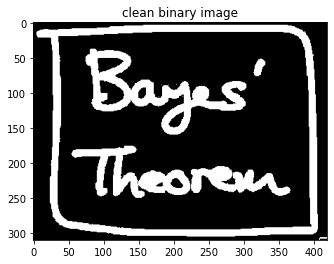

In [3]:
#load image data
data = Image.open('bayes.bmp')
img = np.double(data)
img_mean = np.mean(img)
clean = +1*(img>img_mean) + -1*(img<img_mean)

plt.figure()
plt.imshow(clean,cmap='Greys')
plt.title("clean binary image")

In [4]:
[M, N] = clean.shape
print(M,N)

310 419


### Add noise to the image to disort it

We distort the image by adding normal error with 0 mean and standard deviation of 0.6 

Text(0.5, 1.0, 'observed noisy image')

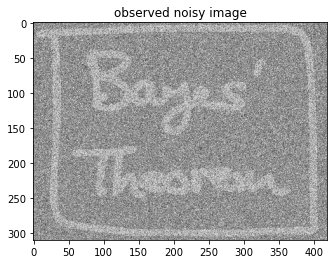

In [5]:
sigma  = 2  #noise level
y = clean + sigma*np.random.randn(M, N) #y_i ~ N(x_i; sigma^2);
plt.figure()
plt.imshow(y, cmap='Greys')
plt.title("observed noisy image")

### Set Variational Bayes hyper-parameters

We assume equal weights W_ij=1, a \lambda of 0.5, while running the algorithm for 15 iterations

In [6]:
J = 1  #coupling strength (w_ij)
rate = 0.5  #update smoothing rate
max_iter = 15
ELBO = np.zeros(max_iter)

### Run the main loop

In [7]:
#Mean-Field VI
print('running mean-field variational inference')
logodds = multivariate_normal.logpdf(y.flatten(), mean=+1, cov=sigma**2) - \
          multivariate_normal.logpdf(y.flatten(), mean=-1, cov=sigma**2)
# y.flatten converts the y matrix into a vector
logodds = np.reshape(logodds, (M, N))

#init
p1 = sigmoid(logodds)
mu = 2*p1-1  #mu_init

a = mu + 0.5 * logodds
qxp1 = sigmoid(+2*a)  #q_i(x_i=+1)
qxm1 = sigmoid(-2*a)  #q_i(x_i=-1)

logp1 = np.reshape(multivariate_normal.logpdf(y.flatten(), mean=+1, cov=sigma**2), (M, N))
logm1 = np.reshape(multivariate_normal.logpdf(y.flatten(), mean=-1, cov=sigma**2), (M, N))

for i in tqdm(range(max_iter)):
    muNew = mu
    for ix in range(N):
        for iy in range(M):
            pos = iy + M*ix
            #The following code sets up the neighbourhood around the index
            neighborhood = pos + np.array([-1,1,-M,M])            
            boundary_idx = [iy!=0,iy!=M-1,ix!=0,ix!=N-1]
            neighborhood = neighborhood[np.where(boundary_idx)[0]]            
            xx, yy = np.unravel_index(pos, (M,N), order='F')
            nx, ny = np.unravel_index(neighborhood, (M,N), order='F')
            
            Sbar = J*np.sum(mu[nx,ny])  
            muNew[xx,yy] = (1-rate)*muNew[xx,yy] + rate*np.tanh(Sbar + 0.5*logodds[xx,yy])
            ELBO[i] = ELBO[i] + 0.5*(Sbar * muNew[xx,yy])
        #end iy for
    #end ix for
    mu = muNew
    a = mu + 0.5 * logodds
    qxp1 = sigmoid(+2*a) #q_i(x_i=+1)
    qxm1 = sigmoid(-2*a) #q_i(x_i=-1)    
    Hx = -qxm1*np.log(qxm1+1e-10) - qxp1*np.log(qxp1+1e-10) #entropy             
    ELBO[i] = ELBO[i] + np.sum(qxp1*logp1 + qxm1*logm1) + np.sum(Hx)

running mean-field variational inference


100%|██████████| 15/15 [00:40<00:00,  2.73s/it]


### Some helpers for visualisation

In [8]:
def show_triptych(x_clean, y_noisy, mu, title="", cmap="gray"):
    """
    x_clean, y_noisy, mu: (M,N) arrays
    mu is in [-1,1]. We display (mu>0) as binary reconstruction.
    """
    recon = (mu > 0).astype(float)
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(x_clean, cmap=cmap)
    ax[0].set_title("Clean (x)")
    ax[0].axis("off")
    ax[1].imshow(y_noisy, cmap=cmap)
    ax[1].set_title("Noisy (y)")
    ax[1].axis("off")
    ax[2].imshow(recon, cmap=cmap)
    ax[2].set_title("Reconstruction (mu>0)")
    ax[2].axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_gallery(mu_snaps, every, cmap="gray"):
    """Show a small gallery of reconstructions over iterations."""
    T = len(mu_snaps)
    cols = min(6, T)
    rows = int(np.ceil(T / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))
    ax = np.array(ax).reshape(-1)
    for i in range(rows*cols):
        ax[i].axis("off")
        if i < T:
            it = i*every
            ax[i].imshow((mu_snaps[i] > 0).astype(float), cmap=cmap)
            ax[i].set_title(f"iter {it}")
    plt.tight_layout()
    plt.show()

Rerun and store data for plotting at different iterations

In [9]:
print('running mean-field variational inference')

# --- your logodds code unchanged up to ELBO init ---
logodds = multivariate_normal.logpdf(y.flatten(), mean=+1, cov=sigma**2) - \
          multivariate_normal.logpdf(y.flatten(), mean=-1, cov=sigma**2)
# y.flatten converts the y matrix into a vector
logodds = np.reshape(logodds, (M, N))

#init
p1 = sigmoid(logodds)
mu = 2*p1-1  #mu_init

a = mu + 0.5 * logodds
qxp1 = sigmoid(+2*a)  #q_i(x_i=+1)
qxm1 = sigmoid(-2*a)  #q_i(x_i=-1)

logp1 = np.reshape(multivariate_normal.logpdf(y.flatten(), mean=+1, cov=sigma**2), (M, N))
logm1 = np.reshape(multivariate_normal.logpdf(y.flatten(), mean=-1, cov=sigma**2), (M, N))

ELBO = np.zeros(max_iter)

# Snapshot settings
snap_every = 2
mu_snaps = []  # will store copies of mu

for i in tqdm(range(max_iter)):
    ELBO[i] = 0.0                       # FIX 1: reset each iter
    muNew = mu.copy()                   # FIX 2: avoid aliasing

    for ix in range(N):
        for iy in range(M):
            pos = iy + M*ix

            neighborhood = pos + np.array([-1, 1, -M, M])
            boundary_idx = [iy != 0, iy != M-1, ix != 0, ix != N-1]
            neighborhood = neighborhood[np.where(boundary_idx)[0]]

            xx, yy = np.unravel_index(pos, (M, N), order='F')
            nx, ny = np.unravel_index(neighborhood, (M, N), order='F')

            # NOTE: for "pure" mean-field you typically use the *previous* mu (old mu),
            # not muNew (partially updated). Your code uses mu (old) which is fine.
            Sbar = J * np.sum(mu[nx, ny])

            muNew[xx, yy] = (1 - rate) * muNew[xx, yy] + rate * np.tanh(Sbar + 0.5 * logodds[xx, yy])

            ELBO[i] += 0.5 * (Sbar * muNew[xx, yy])

    mu = muNew

    a = mu + 0.5 * logodds
    qxp1 = sigmoid(+2 * a)
    qxm1 = sigmoid(-2 * a)

    Hx = -qxm1*np.log(qxm1 + 1e-10) - qxp1*np.log(qxp1 + 1e-10)
    ELBO[i] += np.sum(qxp1 * logp1 + qxm1 * logm1) + np.sum(Hx)

    if (i % snap_every) == 0:
        mu_snaps.append(mu.copy())

running mean-field variational inference


100%|██████████| 15/15 [00:44<00:00,  2.97s/it]


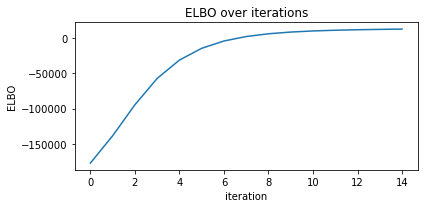

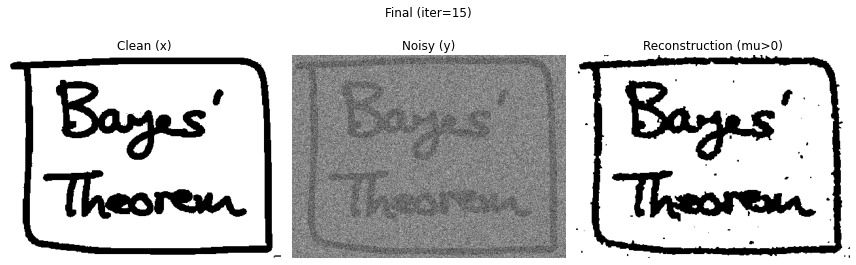

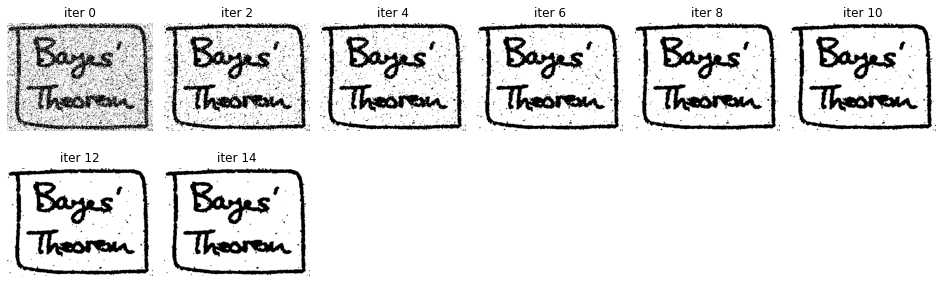

In [10]:
# After inference:
plt.figure(figsize=(6, 3))
plt.plot(ELBO)
plt.title("ELBO over iterations")
plt.xlabel("iteration")
plt.ylabel("ELBO")
plt.tight_layout()
plt.show()

# Visualize evolution (requires you to have x_clean and y already):
show_triptych(clean, y, mu, title=f"Final (iter={max_iter})")
show_gallery(mu_snaps, every=snap_every)

### Plot ELBO to check convergence

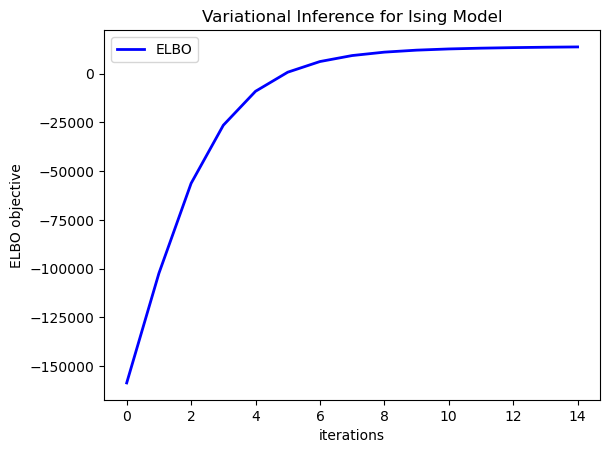

In [7]:
plt.figure()
plt.plot(ELBO, color='b', lw=2.0, label='ELBO')
plt.title('Variational Inference for Ising Model')
plt.xlabel('iterations'); plt.ylabel('ELBO objective')
plt.legend(loc='upper left')

### Finally check if the image was restored

Text(0.5, 1.0, 'after 15 mean-field iterations')

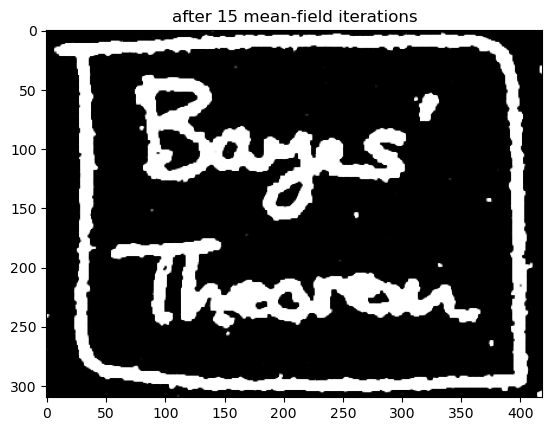

In [8]:
plt.figure()
plt.imshow(mu,cmap='Greys')
plt.title("after %d mean-field iterations" %max_iter)

### Activity 1

Repeat the previous procedure changing some the specifications. For example you can try 
 - adding more noise
 - changing the smoothing rate 
 - having different sigma than the one used to distort the image. 

# Text Classification 

Import the 20 newsgroups dataset, which is a collection of approximately 20,000 newsgroup documents, partitioned (nearly) evenly across 20 different newsgroups. It was originally collected by Ken Lang. The 20 newsgroups collection has become a popular data set for experiments in text applications of machine learning techniques, such as text classification and text clustering.

In [11]:
from sklearn.datasets import fetch_20newsgroups
twenty_train = fetch_20newsgroups(subset='train', shuffle=True)
twenty_train.target_names #prints all the categories

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [12]:
print(twenty_train.data[0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







### Import text into a Document-Term matrix using the Count Vectorizer

The following code will create a huge sparse Document - term matrix, the rows of which represent words and the columns represent the number of times the words appear in a particular document

In [15]:
count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(twenty_train.data)
Xnames = count_vect.get_feature_names_out()
X_train_counts.shape

AttributeError: 'CountVectorizer' object has no attribute 'get_feature_names_out'

In [22]:
print(Xnames[109000:109100])
print(X_train_counts.toarray()[100,109000:109100])

['southerners' 'southgate' 'southington' 'southward' 'southwest'
 'southwestern' 'southwick' 'southy' 'souvenir' 'souvenirs' 'souviens'
 'souvlaki' 'souza' 'souzexpertisa' 'sov' 'sovam' 'soveit' 'sovereign'
 'sovereignity' 'sovereigns' 'sovereignties' 'sovereignty' 'sovergnty'
 'soveriegn' 'soverign' 'soviet' 'soviets' 'sovyet' 'sow' 'soweit'
 'sowell' 'sowetos' 'sowing' 'sown' 'sowrds' 'sox' 'soy' 'soya' 'soybeans'
 'soykirimi' 'soyledikleri' 'soylent' 'soyuz' 'soyuzkarta' 'sp' 'sp1'
 'sp1henhj' 'sp1marse' 'sp1x6fnjk8b' 'sp2' 'sp2c' 'sp2io' 'sp3' 'sp3a'
 'sp4' 'sp9' 'sp94' 'sp99li' 'sp9ii' 'spa' 'spac' 'space' 'space1'
 'spaceball' 'spacebar' 'spacecause' 'spacecoast' 'spacecraft' 'spaced'
 'spacedigestarchive' 'spacedrive' 'spacefight' 'spaceflight' 'spacefood'
 'spacehab' 'spaceknight' 'spacelab' 'spacelanes' 'spacelifter'
 'spacelink' 'spaceman' 'spacenet' 'spacenews' 'spacepac' 'spacer'
 'spaces' 'spaceship' 'spacesuits' 'spacetime' 'spacewalk' 'spacewalking'
 'spacewalks' 'spacew

### TF:  
Just counting the number of words in each document has 1 issue: it will give more weightage to longer documents than shorter documents. To avoid this, we can use frequency (TF - Term Frequencies) i.e. #count(word) / #Total words, in each document.

### TF-IDF: 
Finally, we can even reduce the weightage of more common words like (the, is, an etc.) which occurs in all document. This is called as TF-IDF i.e Term Frequency times inverse document frequency.

We can achieve both using below line of code:

In [16]:
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
X_train_tfidf.shape

(11314, 130107)

### Fit the multinomial Naive Bayes classifier

Use .fit in order to fit the multinomial Naive Bayes classifier to a set of data (X matrix) and a categorical target

In [17]:
clf = MultinomialNB().fit(X_train_tfidf, twenty_train.target)

### Using Pipeline

We can put all the processing steps together so that we don't have to re write them when considering other data

In [18]:
text_clf = Pipeline([('vect', CountVectorizer()),
                     ('tfidf', TfidfTransformer()),
                     ('clf', MultinomialNB())])
text_clf = text_clf.fit(twenty_train.data, twenty_train.target)

### Evaluate the Predictive Performance of the Naive Bayes Classifier

Check against a test (unseen) subset of the data

In [19]:
twenty_test = fetch_20newsgroups(subset='test', shuffle=True)
predicted = text_clf.predict(twenty_test.data) 
print('accuracy rate: ')
print(np.mean(predicted == twenty_test.target))

accuracy rate: 
0.7738980350504514


### Improving performance

We can improve the performance by removing stop words
ii. reducing the Laplace smoothing, setting alpha to 0.1 rather than the default which is 1.

In [20]:
text_clf = Pipeline([('vect', CountVectorizer(stop_words='english')),
                     ('tfidf', TfidfTransformer(sublinear_tf=True)),
                     ('clf', MultinomialNB(alpha=0.1))])
text_clf = text_clf.fit(twenty_train.data, twenty_train.target)
predicted = text_clf.predict(twenty_test.data) 
print('accuracy rate: ')
print(np.mean(predicted == twenty_test.target))

accuracy rate: 
0.8384227296866702


### Activity 2

Experiment by trying different options on the user-specified parameters

In [25]:
text_clf = Pipeline([('vect', CountVectorizer(stop_words='english')),
                     ('tfidf', TfidfTransformer(sublinear_tf=True)),
                     ('clf', MultinomialNB(alpha=0.061))])
text_clf = text_clf.fit(twenty_train.data, twenty_train.target)
predicted = text_clf.predict(twenty_test.data) 
print('accuracy rate: ')
print(np.mean(predicted == twenty_test.target))

accuracy rate: 
0.8425385023898035


### Logistic Regression 

In [26]:
text_logreg = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('clf', LogisticRegression(max_iter=2000))
])
text_logreg.fit(twenty_train.data, twenty_train.target)
pred = text_logreg.predict(twenty_test.data)

print('accuracy rate: ')
print(np.mean(pred == twenty_test.target))

accuracy rate: 
0.8274030801911842


In [29]:
bayes_logit_map = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=10.0,              # try 1.0, 2.0, 4.0
        solver="lbfgs",
        max_iter=2000
    ))
])

bayes_logit_map.fit(twenty_train.data, twenty_train.target)
pred = bayes_logit_map.predict(twenty_test.data)
print('accuracy rate: ')
print(np.mean(pred == twenty_test.target))

accuracy rate: 
0.8445300053106745


### Activity 3

Discuss the differences between the Naive Bayes Classifier and Logistic Regression models